In [1]:
!pip install sentence-transformers seaborn matplotlib

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
sentences = [
    # Cricket
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "India won the cricket match by 5 wickets",
    "The fielder took an amazing catch",

    # Cooking
    "Add spices to enhance the flavor of the dish",
    "Boil the pasta until it is cooked",
    "Chop vegetables before cooking",

    # Cybersecurity
    "Strong passwords protect against cyber attacks",
    "Encryption secures sensitive data",
    "Firewalls block unauthorized access"
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

print(embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(10, 384)


In [5]:
similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

[[ 9.99999881e-01  3.83872092e-01  5.51475108e-01  3.03192139e-01
  -1.02730915e-02 -2.66799182e-02  7.76652917e-02  7.61056542e-02
   7.98735023e-03 -7.65796378e-03]
 [ 3.83872092e-01  1.00000000e+00  3.47994864e-01  4.64989960e-01
   7.53320456e-02  1.33709073e-01  1.70765862e-01  1.10176206e-01
   4.05857116e-02 -3.96799147e-02]
 [ 5.51475108e-01  3.47994864e-01  1.00000000e+00  2.65944153e-01
   6.54174313e-02  2.24216133e-02  9.58841965e-02  1.09942764e-01
   1.02245003e-01  3.18483673e-02]
 [ 3.03192139e-01  4.64989960e-01  2.65944153e-01  1.00000000e+00
   1.01885393e-01 -2.42211670e-03  5.64054102e-02  4.68153618e-02
  -6.92686215e-02  6.82199225e-02]
 [-1.02730915e-02  7.53320456e-02  6.54174313e-02  1.01885393e-01
   1.00000000e+00  1.84462592e-01  2.50230849e-01  4.66508530e-02
   1.42115317e-02  6.98996782e-02]
 [-2.66799182e-02  1.33709073e-01  2.24216133e-02 -2.42211670e-03
   1.84462592e-01  1.00000048e+00  2.88933486e-01  1.67000163e-02
  -4.71312553e-04  9.12104249e-02

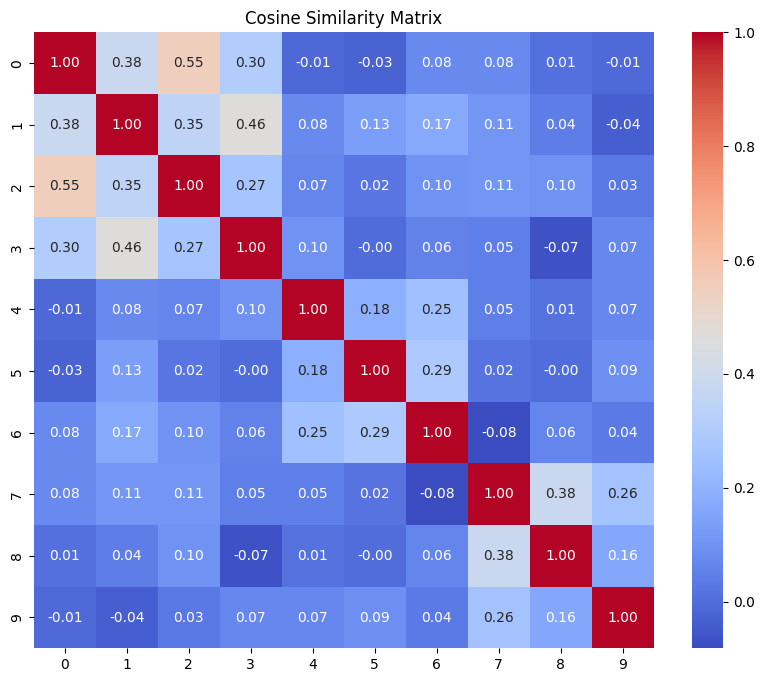

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Cosine Similarity Matrix")
plt.show()

In [7]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = np.argsort(similarities)[-2:][::-1]

for idx in top_indices:
    print("Sentence:", sentences[idx])
    print("Score:", similarities[idx])

Sentence: India won the cricket match by 5 wickets
Score: 0.6856405
Sentence: The batsman scored a century in the match
Score: 0.56821966
